<span style="color: red"; style="font-size:18px"> Acordos de Cessar-Fogo em zonas de conflito </span>

Evento escolhido: Acordos de Cessar-Fogo (Ceasefire) em zonas de conflito.

Hipótese inicial: Mercados de cessar-fogo (ceasefire) são extremamente suscetíveis a falsos positivos: um boato diplomático surge, a probabilidade dispara impulsionada por investidores especulativos e, horas depois, um porta-voz oficial nega o acordo, fazendo o mercado desabar. Notícias não confirmadas sobre tréguas causam picos de volume que desviam significativamente da média histórica recente (identificáveis via Z-Score). Investidores que entram nesses topos sofrem perdas quando a probabilidade sofre um "crash" após o desmentido.

Pergunta inicial: Boatos especulativos de cessar-fogo causam um pico anormal de injeção de capital?

Período analisado: 20/04/2026 até 01/05/2026.

In [ ]:
import pandas as pd

### 1. Identificação do Mercado
    O resultado da extração foi salvo localmente como `Q1_ceasefire.csv` dentro do diretório `dados/`. A leitura e a visualização inicial desses dados confirmam o mercado que será o alvo da nossa análise.

In [ ]:
-- Tamanho: 133,74 MB

SELECT 
  market_id, 
  question, 
  event_title, 
  volume, 
  created_at, 
  end_date, 
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%ceasefire%' 
   OR LOWER(event_title) LIKE '%ceasefire%'
ORDER BY volume DESC
LIMIT 20;

In [103]:
q1 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q1_ceasefire.csv')
q1.head(6)

,market_id,question,event_title,volume,created_at,end_date,answer1,answer2,closed
0,2036399,"US x Iran ceasefire extended by April 22, 2026?",US x Iran ceasefire extended by...?,2.785274e+08,2026-04-20 19:28:43.000000 UTC,2026-04-21 00:00:00.000000 UTC,Yes,No,1
1,1706788,US x Iran ceasefire by April 7?,US x Iran ceasefire by...?,1.736962e+08,2026-03-24 17:52:05.000000 UTC,2026-04-07 00:00:00.000000 UTC,Yes,No,1
2,1994007,"Israel x Hezbollah ceasefire by April 18, 2026?",Israel x Hezbollah ceasefire by...?,9.843824e+07,2026-04-15 20:21:26.000000 UTC,2026-04-15 00:00:00.000000 UTC,Yes,No,1
3,516719,Russia x Ukraine ceasefire in 2025?,Russia x Ukraine ceasefire in 2025?,7.375299e+07,2024-12-29 18:47:35.000000 UTC,2025-12-31 12:00:00.000000 UTC,Yes,No,1
4,552649,Israel x Iran ceasefire before July?,Israel x Iran ceasefire before July?,5.177989e+07,2025-06-15 17:52:19.000000 UTC,2025-06-30 23:55:00.000000 UTC,Yes,No,1
5,1466015,US x Iran ceasefire by March 31?,US x Iran ceasefire by...?,4.437600e+07,2026-02-28 13:44:02.000000 UTC,2026-04-16 00:42:08.000000 UTC,Yes,No,1


O evento com maior volume em nossa base de dados é o contrato sobre o cessar-fogo entre Estados Unidos e Irã, que ficou aberto apenas entre 20 e 21 de abril de 2026. Esse pico de negociações reflete o histórico de conflito entre os dois países. Embora tivessem formado uma aliança política em 1953, a Revolução Iraniana de 1979 gerou uma ruptura nas relações. Foi nesse cenário que ocorreram as negociações de 2026. Em 8 de abril, com mediação do Paquistão, os países firmaram uma trégua inicial. Mesmo com violações do acordo por ambos os lados, o presidente Trump estendeu o cessar-fogo no dia 21 de abril. Essa é a data exata que coincide com a explosão de volume e o pânico no mercado. A instabilidade continuou na vida real: as nações assinaram um memorando de paz em 17 de junho, mas a tentativa falhou e o cessar-fogo foi cancelado em 8 de julho.
Essas rápidas mudanças na diplomacia explicam a alta volatilidade e latência capturada pela análise.

### 2. Evolução Diária do evento entre EUA vs Irã

In [ ]:
-- Tamanho: 201,68 MB

SELECT 
  trade_date,
  event_title,
  avg_trade_price AS probabilidade_media,
  max_trade_price AS probabilidade_maxima,
  min_trade_price AS probabilidade_minima,
  ROUND(max_trade_price - min_trade_price, 3) AS amplitude_dia,
  daily_usd_volume,
  daily_trade_count AS total_transacoes
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
WHERE market_id = '2036399'
ORDER BY trade_date;

In [104]:
q2 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q2_1_ceasefire.csv')
q2['trade_date'] = pd.to_datetime(q2['trade_date'])
q2

,trade_date,event_title,probabilidade_media,probabilidade_maxima,probabilidade_minima,amplitude_dia,daily_usd_volume,total_transacoes
0,2026-04-20,US x Iran ceasefire extended by...?,0.513394,0.750,0.220,0.530,5285.33,221
1,2026-04-21,US x Iran ceasefire extended by...?,0.499611,0.990,0.010,0.980,358248.05,6318
2,2026-04-22,US x Iran ceasefire extended by...?,0.452000,0.960,0.040,0.920,1210055.10,17247
3,2026-04-23,US x Iran ceasefire extended by...?,0.383798,0.999,0.001,0.998,2126255.06,10191
4,2026-04-24,US x Iran ceasefire extended by...?,0.580462,0.999,0.001,0.998,3414189.70,998
5,2026-04-25,US x Iran ceasefire extended by...?,0.806297,0.999,0.001,0.998,4261908.46,492
6,2026-04-26,US x Iran ceasefire extended by...?,0.485842,0.999,0.001,0.998,15076890.14,1161
7,2026-04-27,US x Iran ceasefire extended by...?,0.523151,0.999,0.001,0.998,18041342.53,1041
8,2026-04-28,US x Iran ceasefire extended by...?,0.590849,0.997,0.001,0.996,9958541.38,1274
9,2026-04-29,US x Iran ceasefire extended by...?,0.570721,0.998,0.001,0.997,19613854.32,1650


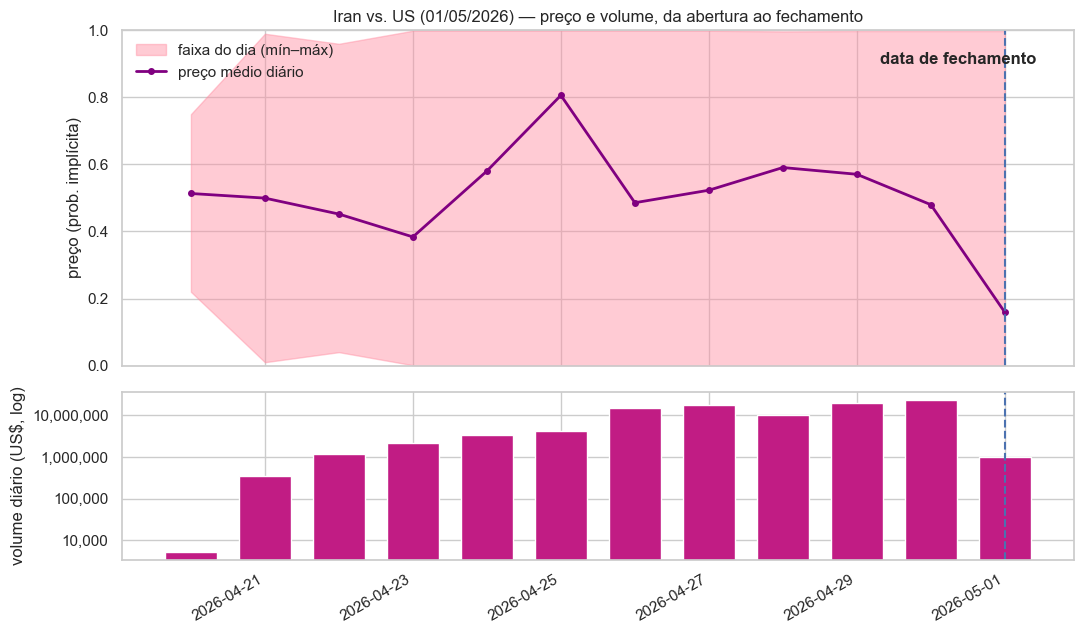

In [108]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DIA = pd.Timestamp("2026-05-01")

# Definindo a paleta
COR1 = "#FF8DA1"
COR2 = "#C11C84"
COR3 = "#C8A2C8"
COR4 = "#800080"

sns.set_theme(style="whitegrid")

q2p = q2[q2["trade_date"] <= DIA]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# Preço: linha do preço médio + faixa min-max do dia
ax1.fill_between(q2p["trade_date"], q2p["probabilidade_minima"], q2p["probabilidade_maxima"],
                  alpha=0.45, color =COR1, label="faixa do dia (mín–máx)")
ax1.plot(q2p["trade_date"], q2p["probabilidade_media"], lw=2,
         marker="o", ms=4, color = COR4, label="preço médio diário")
ax1.axvline(DIA,  ls="--", lw=1.5)
ax1.annotate("data de fechamento", xy=(DIA, 0.9), xytext=(-90, 0),
             textcoords="offset points", fontweight="bold")
ax1.set_ylabel("preço (prob. implícita)")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("Iran vs. US (01/05/2026) — preço e volume, da abertura ao fechamento")

ax2.bar(q2p["trade_date"], q2p["daily_usd_volume"], color=COR2, width=0.7)
ax2.set_yscale("log")
ax2.set_ylabel("volume diário (US$, log)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.axvline(DIA, ls="--", lw=1.5)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

Nota-se que o volume transacional continua por 8 dias após o evento devido à latência de resolução da rede ou eventuais disputas sobre os termos do cessar-fogo. No Polymarket, o evento acontecer no mundo real (ex: saiu a notícia do cessar-fogo) não fecha o mercado instantaneamente. Um "Oráculo"(sistema de verificação) precisa ser acionado para validar a notícia e decretar a resposta. Entre o fato acontecer e o Oráculo bater o martelo, o mercado tecnicamente continua aberto. Se a resolução do Oráculo for contestada pela comunidade (muito comum em temas geopolíticos ambíguos), o mercado entra em modo de disputa. Durante esse tempo extra, a negociação de cotas continua rolando enquanto o comitê avalia as provas.

### 3. Análise de Anomalia: Trades Pós-Evento
    Durante a exploração, identificou-se um comportamento contraintuitivo: o mercado continuou registrando um alto volume de negociações mesmo após o dia 21, data em que o cessar-fogo foi de fato declarado. 
    Em vez de tratar esses dados como ruído e excluí-los, esta análise investiga o fenômeno. Em mercados de previsão descentralizados, o encerramento do contrato não é imediato ao fato. Há uma dependência da validação de um "Oráculo" (sistema de verificação). A query a seguir divide o fluxo de capital em dois momentos distintos:
        1. **Fase Especulativa:** Trades realizados até o dia 20 (tentando prever o futuro).
        2. **Fase de Latência:** Trades realizados a partir do dia 21, onde investidores compram cotas de quem deseja liquidez imediata antes da resolução oficial da plataforma.

In [ ]:
-- Tamanho: 273,31 MB

SELECT 
  CASE 
    WHEN t.trade_timestamp < TIMESTAMP('2026-04-21 00:00:00') THEN '1. Fase Especulativa (Antes do Fato)'
    ELSE '2. Fase de Latência (Pós-Fato)'
  END AS momento_do_mercado,
  
  COUNT(t.trade_timestamp) AS total_de_operacoes,
  COUNT(DISTINCT t.maker) AS carteiras_unicas_envolvidas,
  ROUND(AVG(t.price), 4) AS preco_medio_praticado,
  ROUND(SUM(t.usd_amount),0) AS volume_total_usd

FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
WHERE t.market_id = '2036399' 
    AND DATE(t.trade_timestamp) BETWEEN '2026-04-20' AND '2026-05-01'
GROUP BY 
  momento_do_mercado
ORDER BY 
  momento_do_mercado ASC;

In [109]:
q3 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q3_ceasefire.csv')
q3

,momento_do_mercado,total_de_operacoes,carteiras_unicas_envolvidas,preco_medio_praticado,volume_total_usd
0,1. Fase Especulativa (Antes do Fato),221,52,0.5134,5285.0
1,2. Fase de Latência (Pós-Fato),44192,1747,0.4603,98754937.0


C:\Users\marce\AppData\Local\Temp\ipykernel_18044\1445492414.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\marce\AppData\Local\Temp\ipykernel_18044\1445492414.py:20: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


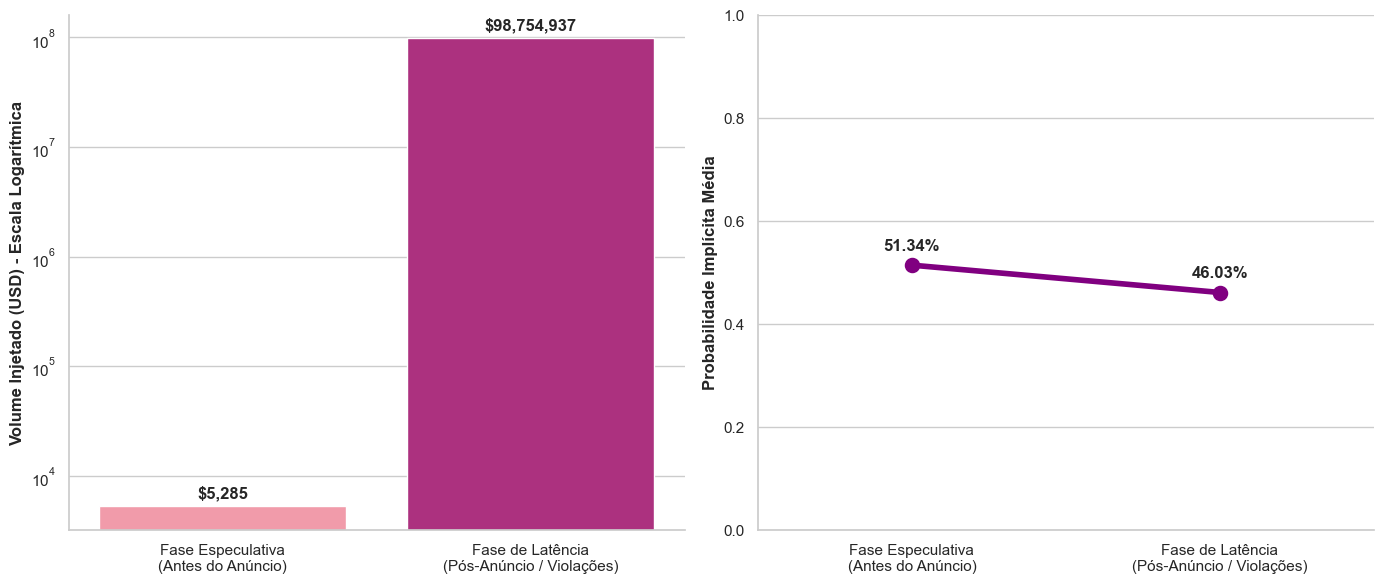

In [111]:
import seaborn as sns
sns.set_theme(style="whitegrid")

df_anomalia = pd.read_csv('dados/Q3_ceasefire.csv')
df_anomalia['Fase_Curta'] = ['Fase Especulativa\n(Antes do Anúncio)', 'Fase de Latência\n(Pós-Anúncio / Violações)']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=df_anomalia, 
    x='Fase_Curta', 
    y='volume_total_usd', 
    palette=[COR1, COR2], 
    ax=ax1
)
ax1.set_yscale("log")
ax1.set_ylabel('Volume Injetado (USD) - Escala Logarítmica', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
for index, row in df_anomalia.iterrows():
    ax1.text(index, row['volume_total_usd'] * 1.2, f"${row['volume_total_usd']:,.0f}", 
             ha='center', fontsize=12, fontweight='bold')
sns.pointplot(
    data=df_anomalia, 
    x='Fase_Curta', 
    y='preco_medio_praticado', 
    color=COR4, 
    markers='o', 
    scale=1.5, 
    ax=ax2
)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Probabilidade Implícita Média', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
for index, row in df_anomalia.iterrows():
    ax2.text(index, row['preco_medio_praticado'] + 0.03, f"{row['preco_medio_praticado'] * 100:.2f}%", 
             ha='center', fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

Embora o cessar-fogo tenha sido anunciado no dia 21, o preço do contrato não atingiu o valor máximo de US$ 0,99; ao contrário, a probabilidade despencou para 46% mesmo com um volume de quase US$ 100 milhões.
Esse comportamento quantitativo confirma o contexto histórico de que a trégua estava sendo constantemente violada por ambos os lados, impedindo o sistema de encerrar o mercado como "Sim" devido à fragilidade do acordo.
A contradição entre a declaração política (dado qualitativo) e a queda da probabilidade sob alto volume (dado quantitativo) gerou uma disputa entre investidores, servindo como um choque estatístico para discussões futuras sobre esse tipo de mercado.

### 4. Rastreamento de grandes investidores após o cessar-fogo

In [ ]:
-- Tamanho: 273,31 MB

SELECT 
  maker AS carteira_investidor,
  COUNT(trade_timestamp) AS qtd_operacoes,
  ROUND(AVG(price), 4) AS preco_medio_exposicao,
  SUM(usd_amount) AS volume_injetado_usd
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '2036399'
    AND DATE(trade_timestamp) BETWEEN '2026-04-20' AND '2026-05-01'
GROUP BY maker
HAVING SUM(usd_amount) > 100000 -- Filtro para carteiras acima de 100 mil dólares
ORDER BY volume_injetado_usd DESC
LIMIT 10;

In [112]:
q4 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q4_ceasefire.csv')
q4

,carteira_investidor,qtd_operacoes,preco_medio_exposicao,volume_injetado_usd
0,0x5BB0De4E97698184eaD80C80cb17A26cD6F6814B,457,0.9729,12517828.08
1,0xd99f3BEc8e060ada0aEf0C4057695DD5BC22fCdc,692,0.9704,9451658.92
2,0x2785E7022dc20757108204B13C08cEa8613b70Ae,346,0.9983,6339267.67
3,0x02e7F29f3E612a95A9cCCA7131CE7DD5D56B59E5,91,0.9970,5674477.52
4,0x7072Dd52161baE614BEC6905846a53c9a3A53413,397,0.9990,4817539.05
5,0x8788Ae76e7516Db143461b211D748578ad9Cc2e5,286,0.9980,4499682.60
6,0xA8B202e6E9a4C2091b6860f1f5c9e9119BbC9a39,282,0.9969,4339866.99
7,0xfdC07e182E6f959256295567E450a8727272FA79,209,0.9965,3289961.72
8,0x6328C267812Df80775801c0a98056609EE0036A4,25,0.9970,3100856.70
9,0xD1C769317BD15De7768A70D0214cf0BBcc531D2B,39,0.9990,2897100.00


### 5. Extração da base para testar as hipóteses

In [ ]:
-- Tamanho: 117 MB

SELECT 
  TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora_referencia,
  
  CASE 
    WHEN trade_timestamp < TIMESTAMP('2026-04-21 00:00:00') THEN 'Especulativa'
    ELSE 'Latencia'
  END AS momento_do_mercado,
  
  COUNT(trade_timestamp) AS total_operacoes_hora,
  ROUND(AVG(price), 4) AS preco_medio_hora,
  SUM(usd_amount) AS volume_usd_hora

FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '2036399'
    AND DATE(trade_timestamp) BETWEEN '2026-04-20' AND '2026-05-01'

GROUP BY 
  hora_referencia,
  momento_do_mercado
ORDER BY 
  hora_referencia ASC;

In [113]:
q5 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q5_ceasefire.csv')
q5.head(20)

,hora_referencia,momento_do_mercado,total_operacoes_hora,preco_medio_hora,volume_usd_hora
0,2026-04-20 19:00:00.000000 UTC,Especulativa,1,0.3800,0.61
1,2026-04-20 20:00:00.000000 UTC,Especulativa,38,0.5021,887.16
2,2026-04-20 21:00:00.000000 UTC,Especulativa,104,0.5057,1313.73
3,2026-04-20 22:00:00.000000 UTC,Especulativa,21,0.4952,150.98
4,2026-04-20 23:00:00.000000 UTC,Especulativa,57,0.5440,2932.85
5,2026-04-21 00:00:00.000000 UTC,Latencia,57,0.4719,1511.15
6,2026-04-21 01:00:00.000000 UTC,Latencia,151,0.5168,2506.16
7,2026-04-21 02:00:00.000000 UTC,Latencia,113,0.5200,4243.14
8,2026-04-21 03:00:00.000000 UTC,Latencia,54,0.5063,2640.92
9,2026-04-21 04:00:00.000000 UTC,Latencia,32,0.4931,988.73


Hipótese:
Se a nossa teoria é que boatos de cessar-fogo causam um pico anormal de injeção de capital, temos que:
Hipótese Nula ($H_0$): O volume financeiro médio horário durante a janela do rumor é igual ou menor ao volume médio em janelas sem rumores ($\mu_{rumor} \le \mu_{normal}$). Não há efeito significativo.
Hipótese Alternativa ($H_1$): O volume financeiro médio horário durante a janela do rumor é significativamente maior do que em períodos sem rumor ($\mu_{rumor} > \mu_{normal}$).

In [ ]:
from scipy import stats

df_teste = pd.read_csv('dados/Q5_ceasefire.csv')

vol_especulativa = df_teste[df_teste['momento_do_mercado'] == 'Especulativa']['volume_usd_hora']
vol_latencia = df_teste[df_teste['momento_do_mercado'] == 'Latencia']['volume_usd_hora']

vol_especulativa = vol_especulativa.fillna(0)
vol_latencia = vol_latencia.fillna(0)

# Utilizaremos o Teste U de Mann-Whitney: O teste U de Mann-Whitney é um método estatístico não paramétrico usado para comparar dois grupos independentes e verificar se eles vêm da mesma população, quando os dados não atendem à suposição de normalidade exigida pelo t-test(RADEČIĆ, 2026). Não temos dados suficientes para acreditar no Teorema Central do Limite.

estatistica_u, p_valor = stats.mannwhitneyu(vol_latencia, vol_especulativa, alternative='greater')

alfa = 0.05 # Como não estamos trabalhando com dados críticos vamos utilizar o teste com 95% de confiança.

print(f"Estatística U: {estatistica_u}")
print(f"Valor-p: {p_valor:.4e}")

if p_valor < alfa:
    print("\nCONCLUSÃO: Rejeitamos H0.")
    print("Há evidências estatísticas suficientes de que o anúncio do cessar-fogo (e suas subsequentes violações) causou um aumento anômalo no volume de negociações em relação ao período especulativo.")
else:
    print("\nCONCLUSÃO: Falhamos em rejeitar H0.")
    print("A diferença de volume entre as fases não é estatisticamente significativa.")

Estatística U: 1112.0
Valor-p: 1.0081e-04

CONCLUSÃO: Rejeitamos H0.
Há evidências estatísticas significativas de que o anúncio do cessar-fogo (e suas subsequentes violações) causou um aumento anômalo no volume de negociações em relação ao período especulativo.


### 6. Dinâmica de Volume/Preço em Múltiplos Mercados de Cessar-Fogo

In [ ]:
-- Tamanho: 144,51 MB

WITH EventosCeasefire AS (
  SELECT '2036399' AS market_id, 'EUA vs Irã' AS nome_evento, DATE('2026-04-21') AS dia_zero UNION ALL
  SELECT '516719' AS market_id, 'Rússia vs Ucrânia' AS nome_evento, DATE('2025-11-21') AS dia_zero UNION ALL # Dia com maior volume
  SELECT '551017' AS market_id, 'Israel vs Hamas' AS nome_evento, DATE('2025-07-22') AS dia_zero 
),

DinamicaMercados AS (
  SELECT
    e.nome_evento,
    -- Calcula a distância em dias para cada evento específico
    DATE_DIFF(e.dia_zero, d.trade_date, DAY) AS dias_antes_do_anuncio,
    (d.max_trade_price - d.min_trade_price) AS amplitude_diaria,
    d.daily_usd_volume
  FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` d
  JOIN EventosCeasefire e 
    ON d.market_id = e.market_id
  -- Filtra a janela de -15 a +15 dias para focar apenas no período crítico de cada evento
  WHERE DATE_DIFF(e.dia_zero, d.trade_date, DAY) BETWEEN -15 AND 15
)

-- Agregação final para o CSV
SELECT
  nome_evento,
  dias_antes_do_anuncio,
  COUNT(*) AS observacoes,
  ROUND(AVG(amplitude_diaria), 4) AS amplitude_media,
  ROUND(AVG(daily_usd_volume), 0) AS volume_medio_usd
FROM DinamicaMercados
GROUP BY 
  nome_evento, 
  dias_antes_do_anuncio
ORDER BY 
  nome_evento, 
  dias_antes_do_anuncio DESC;

In [115]:
q6 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q6_ceasefire.csv')
q6

,nome_evento,dias_antes_do_anuncio,observacoes,amplitude_media,volume_medio_usd
0,EUA vs Irã,1,1,0.530,5285.0
1,EUA vs Irã,0,1,0.980,358248.0
2,EUA vs Irã,-1,1,0.920,1210055.0
3,EUA vs Irã,-2,1,0.998,2126255.0
4,EUA vs Irã,-3,1,0.998,3414190.0
...,...,...,...,...,...
64,Rússia vs Ucrânia,-11,1,0.890,1080520.0
65,Rússia vs Ucrânia,-12,1,0.920,336687.0
66,Rússia vs Ucrânia,-13,1,0.920,429687.0
67,Rússia vs Ucrânia,-14,1,0.920,154522.0


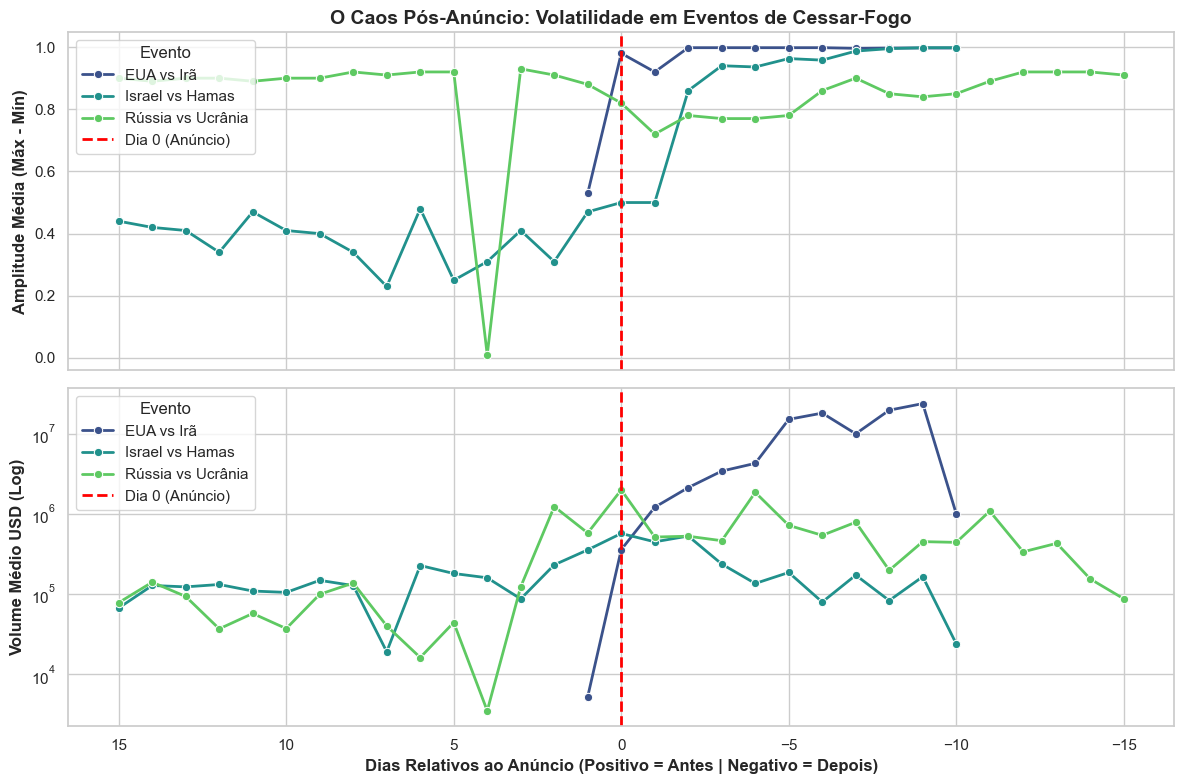

In [116]:
df_q6 = pd.read_csv('dados/Q6_ceasefire.csv')

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

paleta = sns.color_palette("viridis", len(df_q6['nome_evento'].unique()))

sns.lineplot(
    data=df_q6, 
    x="dias_antes_do_anuncio", 
    y="amplitude_media", 
    hue="nome_evento", 
    marker="o", 
    palette=paleta, 
    linewidth=2,
    ax=ax1
)

ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label="Dia 0 (Anúncio)")
ax1.set_ylabel("Amplitude Média (Máx - Mín)", fontweight='bold')
ax1.set_title("O Caos Pós-Anúncio: Volatilidade em Eventos de Cessar-Fogo", fontsize=14, fontweight='bold')
ax1.legend(title="Evento", loc="upper left", frameon=True)
ax1.invert_xaxis() # Esquerda (Antes) para Direita (Depois)

sns.lineplot(
    data=df_q6, 
    x="dias_antes_do_anuncio", 
    y="volume_medio_usd", 
    hue="nome_evento", 
    marker="o", 
    palette=paleta, 
    linewidth=2,
    ax=ax2
)

ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label="Dia 0 (Anúncio)")
ax2.set_yscale("log")
ax2.legend(title="Evento", loc="upper left", frameon=True)
ax2.set_ylabel("Volume Médio USD (Log)", fontweight='bold')
ax2.set_xlabel("Dias Relativos ao Anúncio (Positivo = Antes | Negativo = Depois)", fontweight='bold')

plt.tight_layout()
plt.show()

Se o cessar-fogo fosse definitivo e o mercado confiasse nele, o volume despencaria a zero logo após o Dia 0 (como ocorre em jogos esportivos quando o juiz apita o fim). O que vemos é o oposto: dias de negociações massivas continuam ocorrendo na porção negativa do eixo X. O nosso caso de estudo original (linha azul escura) é o fenômeno mais extremo. Antes do Dia 0, o volume era pífio (abaixo de $10^4$). A partir do anúncio, o capital explode verticalmente, cruzando a barreira dos 10 milhões de dólares diários ($10^7$) e se mantendo nesse patamar durante quase dez dias pós-anúncio (do dia 0 ao -10). As evidências extraídas dos dados comprovam que eventos de cessar-fogo possuem um padrão de alta latência e ceticismo. O anúncio diplomático oficial não é visto pelos investidores como uma resolução, e sim como o início de uma janela de teste. A assinatura de um memorando de paz no mundo real não encerra o mercado na hora. Como vimos, o volume de quase 98 milhões de dólares ocorreu após o anúncio oficial (na Fase de Latência), porque a trégua estava sendo violada.

### 7. Alertas
    Objetivo: Implementar dois alertas atuando em conjunto sobre a mesma base temporal.
        - Alerta 1: Modelagem de Z-Score para identificar injeção de volume a mais de 3 desvios padrões.
        - Alerta 2: Rolling Window (Lag) para detectar crash de probabilidade (queda > 15%).

In [ ]:
-- Tamanho: 172,79 MB

WITH BaseHoraria AS (
  SELECT 
    market_id,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS janela_tempo,
    COUNT(trade_timestamp) AS qtd_trades,
    SUM(usd_amount) AS volume_usd,
    AVG(price) AS preco_medio,
    MAX(price) AS preco_maximo,
    MIN(price) AS preco_minimo
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '2036399'
    AND DATE(trade_timestamp) BETWEEN '2026-04-20' AND '2026-05-01'

  GROUP BY 
    market_id, 
    janela_tempo
),

MetricasEstatisticas AS (
  SELECT 
    market_id,
    janela_tempo,
    qtd_trades,
    volume_usd,
    preco_medio,
    
    AVG(volume_usd) OVER (
      PARTITION BY market_id 
      ORDER BY UNIX_MICROS(janela_tempo) 
      RANGE BETWEEN 86400000000 PRECEDING AND CURRENT ROW 
    ) AS media_mov_vol_24h,
    
    -- Desvio Padrão Amostral do Volume (Para o cálculo de variância e Z-Score)
    STDDEV(volume_usd) OVER (
      PARTITION BY market_id 
      ORDER BY UNIX_MICROS(janela_tempo) 
      RANGE BETWEEN 86400000000 PRECEDING AND CURRENT ROW
    ) AS dp_vol_24h,
    
    -- Captura do preço da hora imediatamente anterior para análise de derretimento
    LAG(preco_medio, 1) OVER (
      PARTITION BY market_id 
      ORDER BY janela_tempo
    ) AS preco_hora_anterior
    
  FROM BaseHoraria
),

Sinalizadores AS (
  SELECT 
    m_est.market_id,
    m_est.janela_tempo,
    m_est.volume_usd,
    m_est.preco_medio,
    
    -- ALERTA 1: Z-Score = (Valor Observado - Média) / Desvio Padrão
    -- Proteção (NULLIF) aplicada para evitar divisão por zero em momentos de liquidez nula
    (m_est.volume_usd - m_est.media_mov_vol_24h) / NULLIF(m_est.dp_vol_24h, 0) AS score_z_volume,
    
    -- ALERTA 2: Variação Percentual (Delta) do Preço Implícito
    (m_est.preco_medio - m_est.preco_hora_anterior) / NULLIF(m_est.preco_hora_anterior, 0) AS delta_preco
    
  FROM MetricasEstatisticas m_est
)

SELECT 
  s.janela_tempo AS data_hora_anomalia,
  m.question AS contexto_mercado,
  ROUND(s.volume_usd, 2) AS volume_injetado,
  ROUND(s.preco_medio, 4) AS probabilidade_atual,
  ROUND(s.score_z_volume, 2) AS z_score_calculado,
  ROUND(s.delta_preco * 100, 2) AS variacao_percentual,
  
  CASE 
    WHEN s.score_z_volume > 3.0 AND s.delta_preco < -0.10 THEN 'ALERTA DUPLO: Fuga de Capital (Z-Score > 3 e Crash > 10%)'
    WHEN s.score_z_volume > 3.0 THEN 'ALERTA 1 (FOMO): Injeção Atípica de Capital (Z-Score > 3)'
    WHEN s.delta_preco < -0.15 THEN 'ALERTA 2 (CRASH): Queda Brusca de Probabilidade (Queda > 15%)'
  END AS gatilho_acionado
  
FROM Sinalizadores s
JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m
  ON s.market_id = m.market_id
  
WHERE s.score_z_volume > 3.0 
   OR s.delta_preco < -0.15
   
ORDER BY s.janela_tempo DESC;

In [117]:
q7 = pd.read_csv('../../banco_de_dados_2/marcelle_suhett_trainee/dados/Q7_ceasefire.csv')
q7

,data_hora_anomalia,contexto_mercado,volume_injetado,probabilidade_atual,z_score_calculado,variacao_percentual,gatilho_acionado
0,2026-05-01 00:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",1001841.42,0.1589,0.01,-54.66,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
1,2026-04-30 23:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",340777.65,0.3505,-0.37,-55.23,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
2,2026-04-30 21:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",234650.89,0.2687,-0.47,-27.66,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
3,2026-04-30 20:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",2168397.60,0.3714,0.30,-47.94,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
4,2026-04-30 19:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",9004523.93,0.7133,3.03,-13.38,ALERTA DUPLO: Fuga de Capital (Z-Score > 3 e C...
...,...,...,...,...,...,...,...
65,2026-04-22 10:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",29413.31,0.5085,0.28,-16.35,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
66,2026-04-22 06:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",7454.30,0.3655,-0.35,-32.33,ALERTA 2 (CRASH): Queda Brusca de Probabilidad...
67,2026-04-21 20:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",145858.03,0.4956,4.75,6.60,ALERTA 1 (FOMO): Injeção Atípica de Capital (Z...
68,2026-04-21 19:00:00.000000 UTC,"US x Iran ceasefire extended by April 22, 2026?",17301.97,0.4650,3.16,0.10,ALERTA 1 (FOMO): Injeção Atípica de Capital (Z...


In [118]:
df_alertas = q7

df_alertas['data_hora_anomalia'] = pd.to_datetime(df_alertas['data_hora_anomalia'])
df_alertas = df_alertas.sort_values('data_hora_anomalia')

contagem_gatilhos = df_alertas['gatilho_acionado'].value_counts()
print("RESUMO DE ALERTAS ACIONADOS")
print(contagem_gatilhos.to_string())

RESUMO DE ALERTAS ACIONADOS
gatilho_acionado
ALERTA 2 (CRASH): Queda Brusca de Probabilidade (Queda > 15%)    57
ALERTA 1 (FOMO): Injeção Atípica de Capital (Z-Score > 3)         9
ALERTA DUPLO: Fuga de Capital (Z-Score > 3 e Crash > 10%)         4


In [119]:
try:
    df = q7
    df['data_hora_anomalia'] = pd.to_datetime(df['data_hora_anomalia'])
    df = df.sort_values('data_hora_anomalia').reset_index(drop=True)
    
    first_alert = df.iloc[0]
    min_price_row = df.loc[df['probabilidade_atual'].idxmin()]
    
    print(f"First alert time: {first_alert['data_hora_anomalia']}")
    print(f"First alert price: {first_alert['probabilidade_atual']}")
    print(f"First alert trigger: {first_alert['gatilho_acionado']}")
    
    print(f"Min price time: {min_price_row['data_hora_anomalia']}")
    print(f"Min price: {min_price_row['probabilidade_atual']}")
    
except Exception as e:
    print(f"Error: {e}")

First alert time: 2026-04-21 10:00:00+00:00
First alert price: 0.6045
First alert trigger: ALERTA 1 (FOMO): Injeção Atípica de Capital (Z-Score > 3)
Min price time: 2026-04-24 22:00:00+00:00
Min price: 0.001


In [120]:
print(df.head()[['data_hora_anomalia', 'probabilidade_atual', 'gatilho_acionado']])

         data_hora_anomalia  probabilidade_atual  \
0 2026-04-21 10:00:00+00:00               0.6045   
1 2026-04-21 19:00:00+00:00               0.4650   
2 2026-04-21 20:00:00+00:00               0.4956   
3 2026-04-22 06:00:00+00:00               0.3655   
4 2026-04-22 10:00:00+00:00               0.5085   

                                    gatilho_acionado  
0  ALERTA 1 (FOMO): Injeção Atípica de Capital (Z...  
1  ALERTA 1 (FOMO): Injeção Atípica de Capital (Z...  
2  ALERTA 1 (FOMO): Injeção Atípica de Capital (Z...  
3  ALERTA 2 (CRASH): Queda Brusca de Probabilidad...  
4  ALERTA 2 (CRASH): Queda Brusca de Probabilidad...  


In [121]:
import pandas as pd

df_backtest = q7
df_backtest['data_hora_anomalia'] = pd.to_datetime(df_backtest['data_hora_anomalia'])
df_backtest = df_backtest.sort_values('data_hora_anomalia').reset_index(drop=True)

primeiro_alerta = df_backtest.iloc[0]
hora_alerta = primeiro_alerta['data_hora_anomalia']
preco_alerta = primeiro_alerta['probabilidade_atual']
tipo_alerta = primeiro_alerta['gatilho_acionado']

fundo_do_poco = df_backtest.loc[df_backtest['probabilidade_atual'].idxmin()]
hora_fundo = fundo_do_poco['data_hora_anomalia']
preco_minimo = fundo_do_poco['probabilidade_atual']

tamanho_posicao = 10000 
valor_no_alerta = tamanho_posicao * preco_alerta
valor_no_fundo = tamanho_posicao * preco_minimo
prejuizo_evitado = valor_no_alerta - valor_no_fundo

print(f"SIMULAÇÃO:")
print(f"\nGatilho Acionado: {tipo_alerta}")
print(f"Data/Hora do Disparo: {hora_alerta}")
print(f"Preço de Saída (Probabilidade): {preco_alerta:.4f} (aprox. {(preco_alerta*100):.1f}%)\n")

print(f"Fundo do Mercado: {hora_fundo}")
print(f"Preço Mínimo Atingido: {preco_minimo:.4f} (aprox. {(preco_minimo*100):.1f}%)\n")

print("RESULTADO FINANCEIRO (Lote de 10.000 Contratos):")
print(f"Capital salvo vendendo no alerta: US$ {valor_no_alerta:,.2f}")
print(f"Capital restante ignorando o alerta: US$ {valor_no_fundo:,.2f}")
print(f"\n> PREJUÍZO EVITADO (CAPITAL PROTEGIDO): US$ {prejuizo_evitado:,.2f}")

SIMULAÇÃO:

Gatilho Acionado: ALERTA 1 (FOMO): Injeção Atípica de Capital (Z-Score > 3)
Data/Hora do Disparo: 2026-04-21 10:00:00+00:00
Preço de Saída (Probabilidade): 0.6045 (aprox. 60.5%)

Fundo do Mercado: 2026-04-24 22:00:00+00:00
Preço Mínimo Atingido: 0.0010 (aprox. 0.1%)

RESULTADO FINANCEIRO (Lote de 10.000 Contratos):
Capital salvo vendendo no alerta: US$ 6,045.00
Capital restante ignorando o alerta: US$ 10.00

> PREJUÍZO EVITADO (CAPITAL PROTEGIDO): US$ 6,035.00


C:\Users\marce\AppData\Local\Temp\ipykernel_18044\214179713.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\marce\AppData\Local\Temp\ipykernel_18044\214179713.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(labels, fontweight='bold')


Dashboard saved as dashboard_final.png


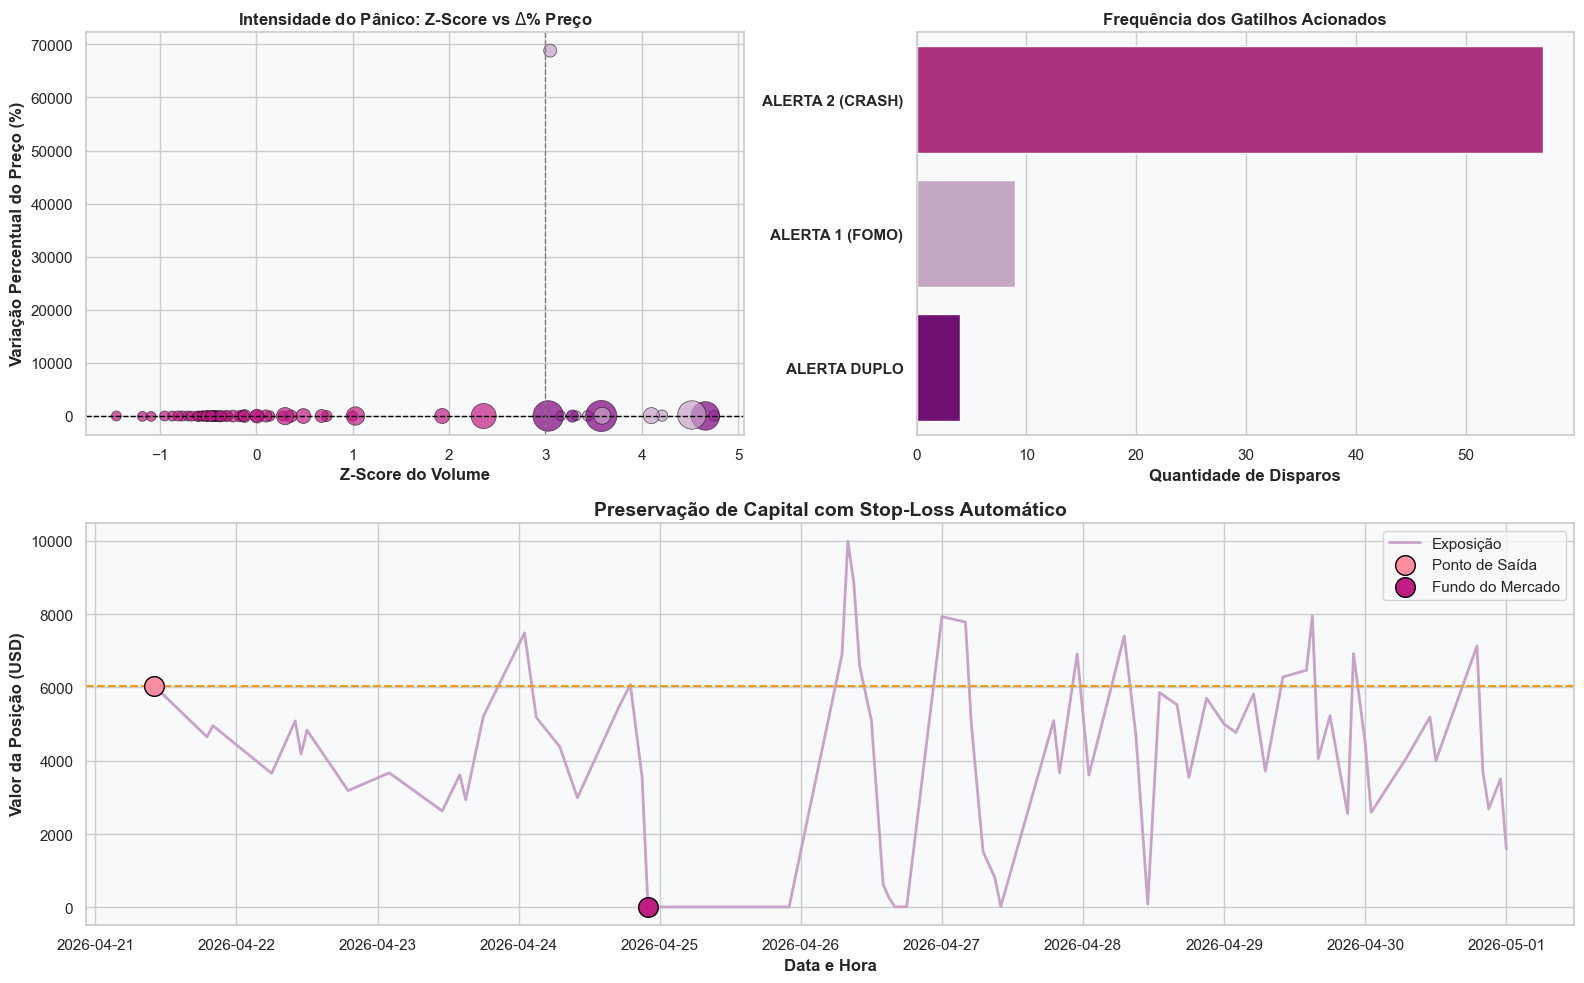

In [122]:
df = q7
df['data_hora_anomalia'] = pd.to_datetime(df['data_hora_anomalia'])
df = df.sort_values('data_hora_anomalia').reset_index(drop=True)

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa"})
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

cores_gatilho = {
    'ALERTA 2 (CRASH): Queda Brusca de Probabilidade (Queda > 15%)': COR2,
    'ALERTA 1 (FOMO): Injeção Atípica de Capital (Z-Score > 3)': COR3,
    'ALERTA DUPLO: Fuga de Capital (Z-Score > 3 e Crash > 10%)': COR4
}

ax1 = fig.add_subplot(gs[0, 0])
sns.scatterplot(
    data=df, 
    x='z_score_calculado', 
    y='variacao_percentual', 
    hue='gatilho_acionado',
    palette=cores_gatilho,
    size='volume_injetado',
    sizes=(50, 500),
    alpha=0.7,
    edgecolor='k',
    ax=ax1
)
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.axvline(3, color='gray', linewidth=1, linestyle='--')
ax1.set_title('Intensidade do Pânico: Z-Score vs $\Delta$% Preço', fontsize=12, fontweight='bold')
ax1.set_xlabel('Z-Score do Volume', fontweight='bold')
ax1.set_ylabel('Variação Percentual do Preço (%)', fontweight='bold')
ax1.legend_.remove() 
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(
    data=df, 
    y='gatilho_acionado', 
    palette=cores_gatilho,
    order=df['gatilho_acionado'].value_counts().index,
    ax=ax2
)
ax2.set_title('Frequência dos Gatilhos Acionados', fontsize=12, fontweight='bold')
ax2.set_xlabel('Quantidade de Disparos', fontweight='bold')
ax2.set_ylabel('')
# shorten y-labels for better fit
labels = [text.get_text().split(':')[0] for text in ax2.get_yticklabels()]
ax2.set_yticklabels(labels, fontweight='bold')

ax3 = fig.add_subplot(gs[1, :])

primeiro_alerta = df.iloc[0]
fundo_do_poco = df.loc[df['probabilidade_atual'].idxmin()]

tamanho_posicao = 10000
valor_inicial = 10000 * 1.0 
df['valor_carteira'] = df['probabilidade_atual'] * tamanho_posicao

ax3.plot(df['data_hora_anomalia'], df['valor_carteira'], color=COR3, linewidth=2, label='Exposição')
ax3.scatter(primeiro_alerta['data_hora_anomalia'], primeiro_alerta['probabilidade_atual'] * tamanho_posicao, 
            color=COR1, s=200, zorder=5, edgecolor='black', label='Ponto de Saída')
ax3.scatter(fundo_do_poco['data_hora_anomalia'], fundo_do_poco['probabilidade_atual'] * tamanho_posicao, 
            color=COR2, s=200, zorder=5, edgecolor='black', label='Fundo do Mercado')

ax3.axhline(primeiro_alerta['probabilidade_atual'] * tamanho_posicao, color='#f39c12', linestyle='--', linewidth=1.5)

ax3.set_title('Preservação de Capital com Stop-Loss Automático', fontsize=14, fontweight='bold')
ax3.set_ylabel('Valor da Posição (USD)', fontweight='bold')
ax3.set_xlabel('Data e Hora', fontweight='bold')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('dashboard_final.png', dpi=300)
print("Dashboard saved as dashboard_final.png")

Gráfico 1 no canto superior esquerdo mostra a correlação entre o choque de volume (eixo X) e o colapso de preço (eixo Y). O tamanho das bolhas revela onde o "dinheiro" atuou. Os pontos roxos (Alerta Duplo) são as anomalias mais violentas da base, onde alto volume e queda de preço ocorreram na mesma hora.
Gráfico 2 no canto superior direito mostra a distribuição da taxonomia do erro. A maior parte das horas anômalas é classificada como "Crash" de preço (vermelho), mas foram os gatilhos laranjas (Injeção Atípica de Capital) que serviram como sinalizadores precoces da falha do cessar-fogo.
O Gráfico 3 na parte inferior da imagem plota o derretimento do valor de uma carteira de 10.000 contratos ao longo dos dias. A marcação laranja mostra onde o algoritmo teria tirado o investidor do mercado (garantindo cerca de US$ 6.000), livrando-o da possibilidade de chegar até a posição da marcação vermelha (onde o valor atingiu US$ 10).